In [109]:
import pandas as pd, numpy as np, seaborn as sns, datetime, sys, matplotlib.pyplot as plt
from pathlib import Path
from astral.sun import sun

from pandas.plotting import scatter_matrix

from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Ajoute le dossier `src/` au chemin d'import Python
sys.path.append(str(Path.cwd().parent / "src"))
from preprocessing_utils import (convert_datetime_columns, 
                                 jour_nuit, 
                                 encode_ordinal_mer, 
                                 encode_direction, 
                                 add_mistral_flag, 
                                 MARSEILLE, 
                                 PARIS_TZ, 
                                 CMAP, 
                                 preprocess_maritime_data
)

## Récupère maritime_clean.csv


#### Annulation :
- 1 = navette annulée
- 0 = navette assurée

In [ ]:
# # === CONFIGURATION ===
# pd.set_option("display.max_columns", None)

# # === CHOIX DU FICHIER A IMPORTER ===
# VP_F_I = pd.read_csv('../data/VP_frioul_if.csv', index_col=0)
# VP_F = pd.read_csv('../data/VP_frioul.csv', index_col=0)
# VP_I = pd.read_csv('../data/VP_if.csv', index_col=0)
# VP_I = pd.read_csv('../data/Frioul_if.csv', index_col=0)

In [ ]:
# # === PRÉTRAITEMENT COMPLET ===
# VP_F_I = preprocess_maritime_data("../data/VP_frioul_if.csv")
# VP_F = preprocess_maritime_data("../data/VP_frioul.csv")
# VP_I = preprocess_maritime_data("../data/VP_if.csv")
# F_I = preprocess_maritime_data("../data/Frioul_if.csv")


# # === Sélections pour analyse ===  exclu le variable horaire
# VP_F_I_numeric = VP_F_I.select_dtypes(include=['number'])
# VP_F_numeric = VP_F.select_dtypes(include=['number'])
# VP_I_numeric = VP_I.select_dtypes(include=['number'])
# F_I_numeric = F_I.select_dtypes(include=['number'])

In [112]:
#  =========================== CHOISIR UN DATAFRAME =============================
# df_numeric = VP_F_I_numeric
# df_numeric = VP_F_numeric
# df_numeric = VP_I_numeric
df_numeric = F_I_numeric
# df = VP_F_I
# df = VP_F
# df = VP_I
df = F_I

In [113]:
df.head(1)


,Horaire,Annulation,VentNoeud,HouleDominante,HouleMax,HoulePeriode,Mer,Temperature,JourNuit,VentMistral,HouleMistral,Bateau_EDantes,Bateau_HJEsperandieu,Bateau_Îles d'or XV,Ciel_Couvert,Ciel_Ensoleillé,Ciel_Partiellement nuageux,Ciel_Pluie forte à modérée avec tonerre par endroit,Ciel_Pluie modérée,Capitaine_Boukobza Marc,Capitaine_Cardamone David,Capitaine_Chatard Laurent,Capitaine_Culcitchi Viorel,Capitaine_Dakarian Vanessa,Capitaine_De gonzaga Boris,Capitaine_Demesy Anthony,Capitaine_Hellmann Nicolas,Capitaine_Hrouchoff-mikhailoff Kevin,Capitaine_Lucs Viktors,Capitaine_Rivière Frédéric,Capitaine_Vieira Soïgan
1614,2024-01-13 14:35:00,0,5.0,0.3,0.5,5.0,1,9.0,0,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


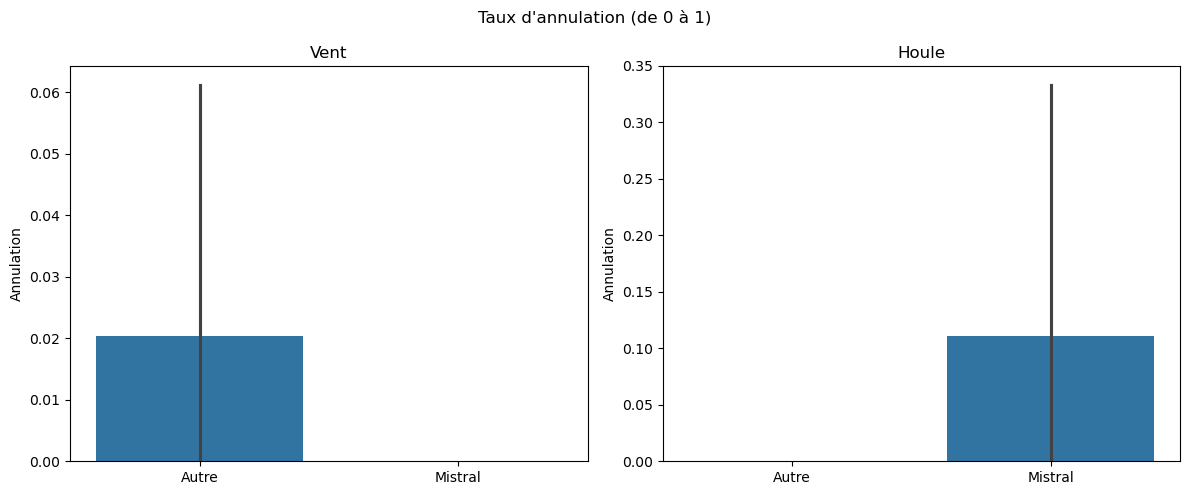

In [114]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# === Vent Mistral ===
sns.barplot(x='VentMistral', y='Annulation', data=df, ax=axs[0])
axs[0].set_title("Vent")
axs[0].set_xlabel('')
axs[0].set_xticks(axs[0].get_xticks())
axs[0].set_xticklabels(['Autre', 'Mistral'])

# === Houle Mistral ===
sns.barplot(x='HouleMistral',  y='Annulation', data=df, ax=axs[1])
axs[1].set_title("Houle")
axs[1].set_xlabel('')
axs[1].set_xticks(axs[1].get_xticks())
axs[1].set_xticklabels(['Autre', 'Mistral'])

plt.suptitle("Taux d'annulation (de 0 à 1)")
plt.tight_layout()
plt.show()


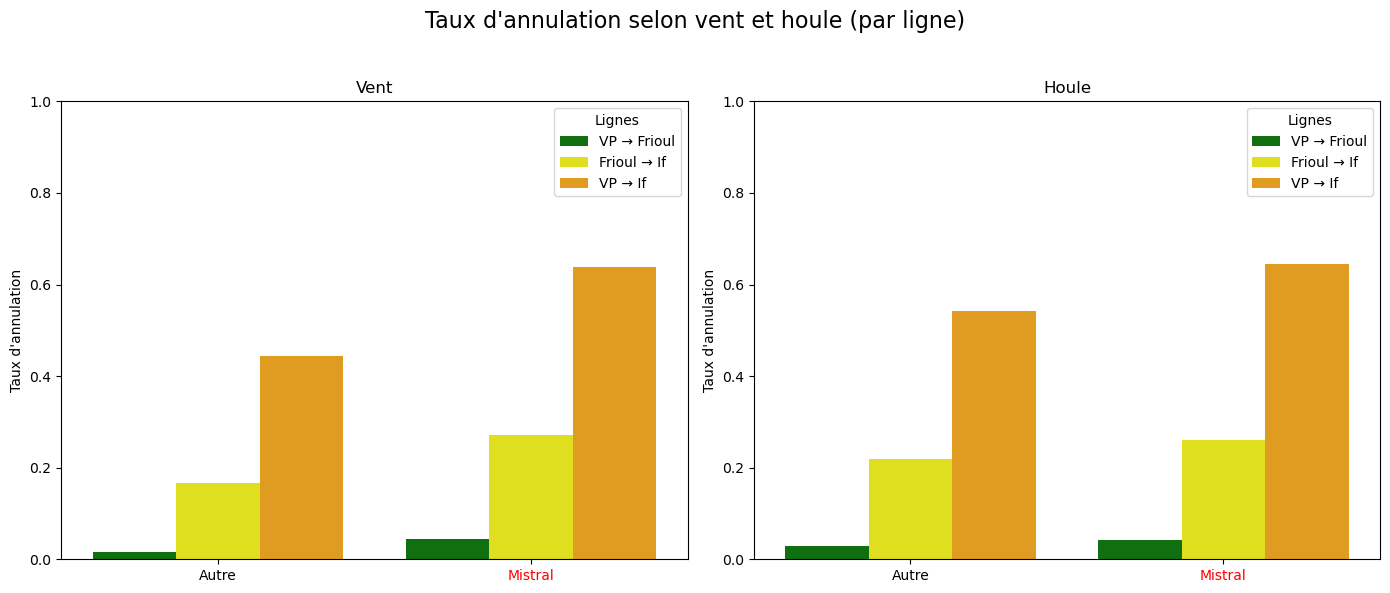

In [71]:
# Liste des DataFrames avec leurs noms et couleurs
lignes = [
    ("VP → Frioul", VP_F, "green"),
    ("Frioul → If", VP_F_I, "yello"),
    ("VP → If", VP_I, "orange")
]

vent_data = []
houle_data = []

for name, df_loop, base_color in lignes:
    # Groupe par présence de Mistral (0: autre, 1: mistral)
    vent_rates = df_loop.groupby("VentMistral")["Annulation"].mean()
    houle_rates = df_loop.groupby("HouleMistral")["Annulation"].mean()

    for val in [0, 1]: # 0: Autre, 1: Mistral
        label = "Mistral" if val == 1 else "Autre"
        vent_data.append({"Lignes": name, "Type": label,"Annulation": vent_rates.get(val, 0)})
        houle_data.append({"Lignes": name, "Type": label, "Annulation": houle_rates.get(val, 0)})

vent_df_loop = pd.DataFrame(vent_data)
houle_df_loop = pd.DataFrame(houle_data)

# === PLOT ===
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Vent
sns.barplot(x="Type", y="Annulation", hue="Lignes", data=vent_df, ax=axs[0], palette={"VP → Frioul": "green", "Frioul → If": "yellow", "VP → If": "orange"})
axs[0].set_title("Vent")
axs[0].set_ylabel("Taux d'annulation")
axs[0].set_xlabel("")
axs[0].set_ylim(0, 1)

# Changer couleur des labels x (Vent)
for label in axs[0].get_xticklabels():
    if label.get_text() == "Mistral":
        label.set_color("red")

# Houle
sns.barplot(x="Type", y="Annulation", hue="Lignes", data=houle_df, ax=axs[1], palette={"VP → Frioul": "green", "Frioul → If": "yellow", "VP → If": "orange"})
axs[1].set_title("Houle")
axs[1].set_ylabel("Taux d'annulation")
axs[1].set_xlabel("")
axs[1].set_ylim(0, 1)

# Changer couleur des labels x (Houle)
for label in axs[1].get_xticklabels():
    if label.get_text() == "Mistral":
        label.set_color("red")

plt.suptitle("Taux d'annulation selon vent et houle (par ligne)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [75]:
df.columns.nunique()

67

## df Numerique

In [76]:
# Compte les na
# print("Nombre de valeurs manquante par variables :\n",df_numeric.isna().sum(),"\n")
# affiche les na si > 0
# print()
print("Liste de variables avec valeurs manquantes :\n",df_numeric.isna().sum()[df_numeric.isna().sum() > 0])

Liste de variables avec valeurs manquantes :
 Series([], dtype: int64)


## Recherche de correlations

In [77]:
# extrait de la matrice la corrélation de Annulation avec toutes les autres variables, triées par ordre décroissant.
target_corr = df_numeric.corr()['Annulation'].sort_values(ascending=False)
print(target_corr)

Annulation                                              1.000000
Mer                                                     0.691281
HouleDominante                                          0.660011
HouleMax                                                0.655643
VentNoeud                                               0.466228
                                                          ...   
Capitaine_Tassier Gery                                 -0.045171
Capitaine_Hellmann Nicolas                             -0.062166
Ciel_Pluie forte à modérée avec tonerre par endroit    -0.065540
Ciel_Ensoleillé                                        -0.100890
Temperature                                            -0.259248
Name: Annulation, Length: 66, dtype: float64


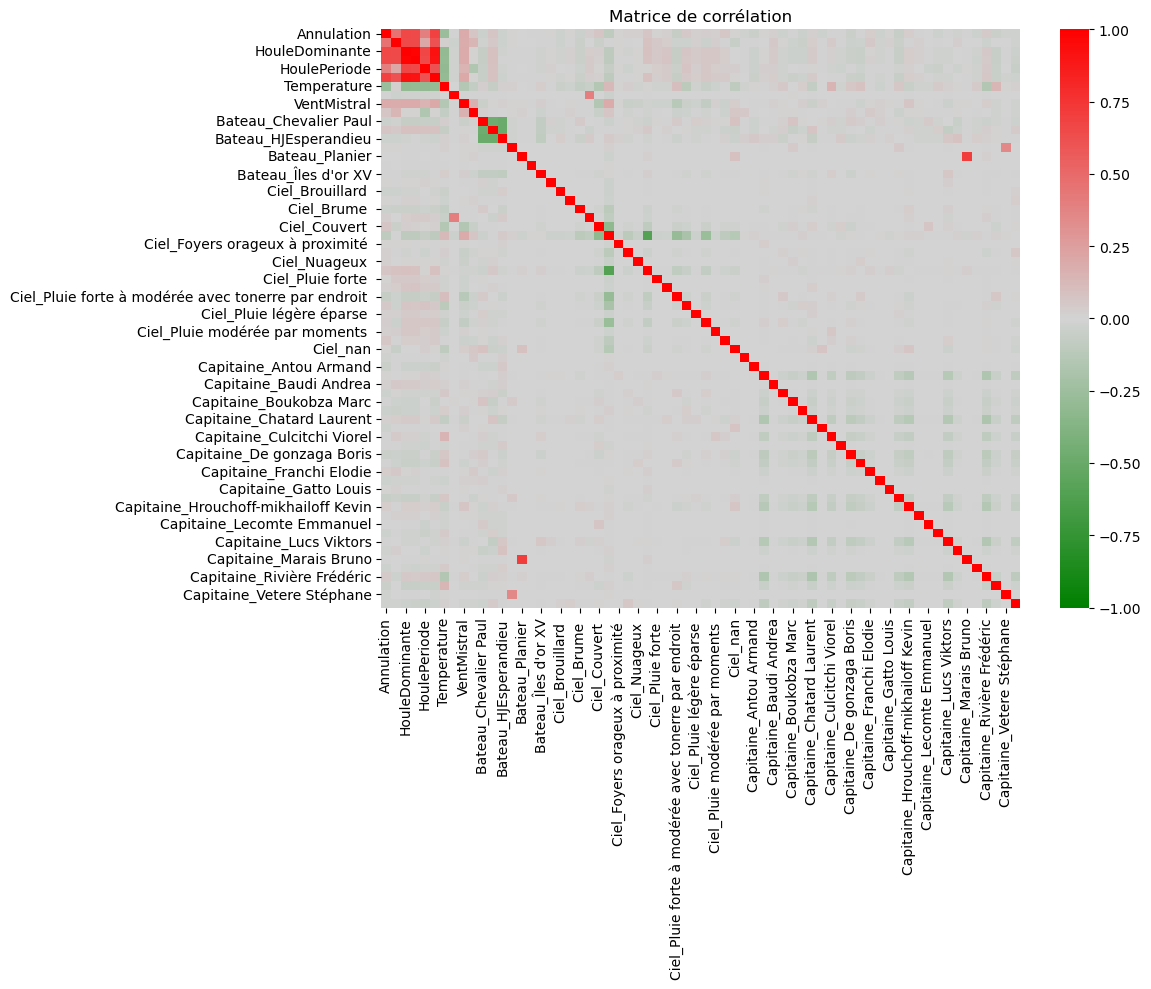

In [78]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_numeric.corr(), cmap=CMAP, center=0, annot=False, vmin=-1, vmax=1)
plt.title('Matrice de corrélation')
# plt.savefig("../exports/matrice_de_correlations.png")
plt.tight_layout()
plt.show()

## Trop de variable, la matrice de correlation est illisible

Text(0.5, 1.0, 'Corrélations des variables avec Annulation')

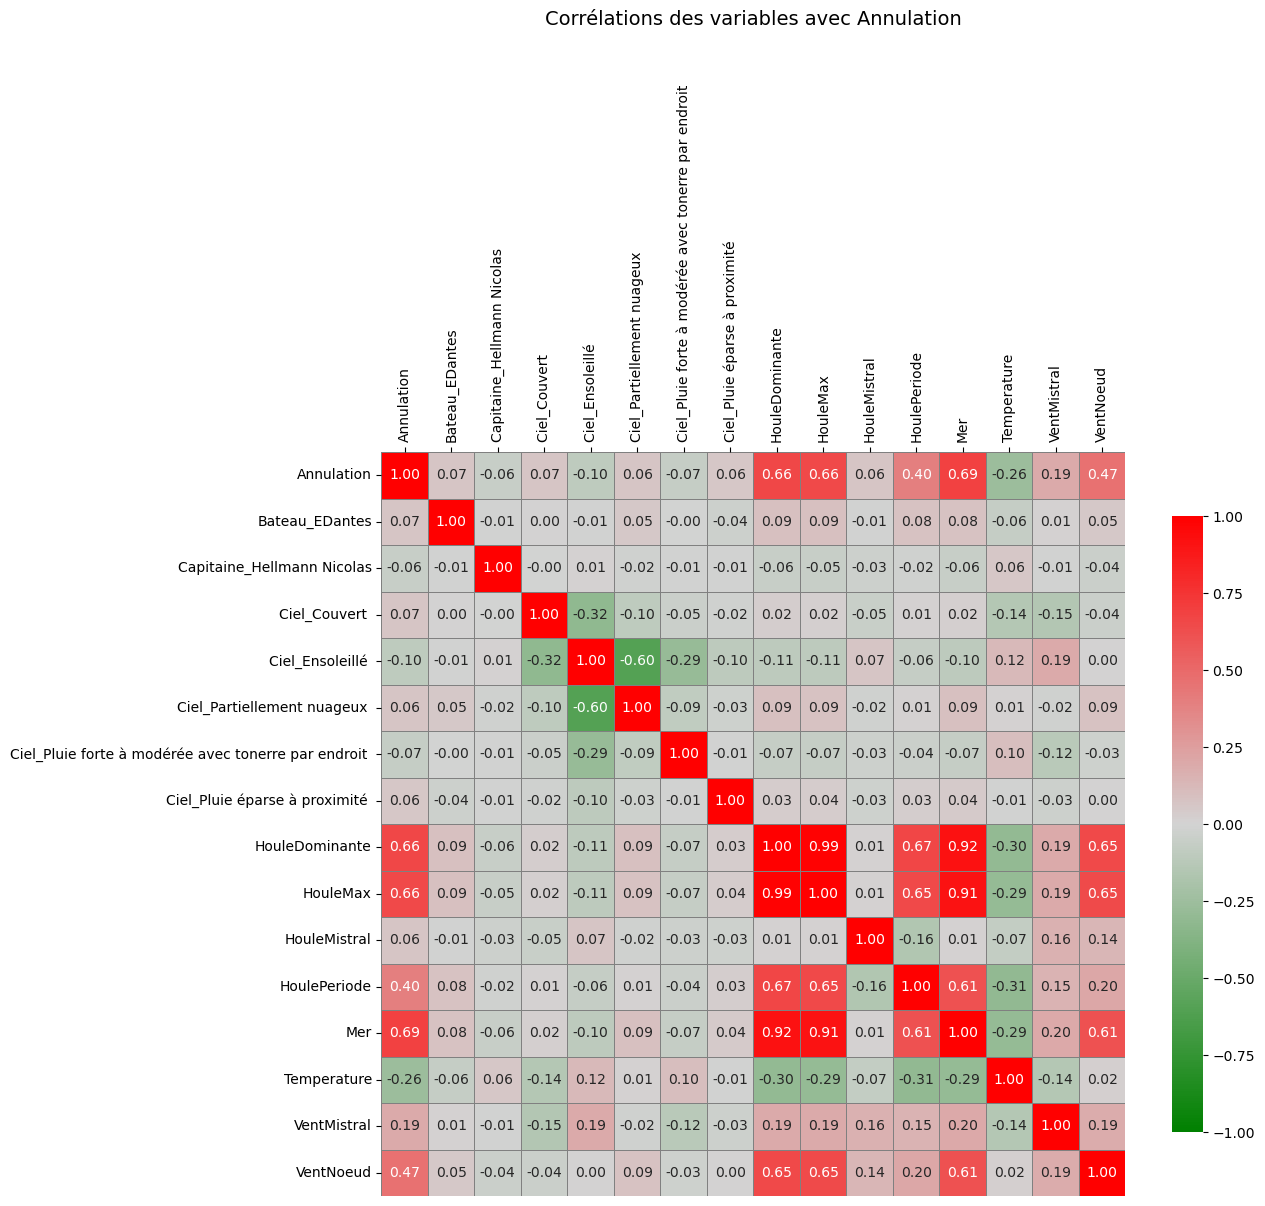

In [79]:
# Choisir les variables les plus pertinentes
SELECTED_VARIABLES = 15

# Calcul de la matrice de corrélation
corr_matrix = df_numeric.corr()

# Variables les plus corrélées avec la cible (hors elle-même)
corr_cible = corr_matrix["Annulation"].drop("Annulation")
top_vars = corr_cible.abs().sort_values(ascending=False).head(SELECTED_VARIABLES).index

# Sous-matrice des corrélations
sub_corr = corr_matrix.loc[top_vars.union(["Annulation"]), top_vars.union(["Annulation"])]

# Affichage avec seaborn heatmap
plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    sub_corr, 
    cmap=CMAP,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5,
    linecolor='gray',
    square=True,
    cbar_kws={"shrink": 0.8}
)

# Déplacer les labels X en haut
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')  # Facultatif : pour déplacer le label de l'axe

# Rotation pour lisibilité
plt.xticks(rotation=90)
plt.title("Corrélations des variables avec Annulation", fontsize=14, pad=40)

# plt.tight_layout()

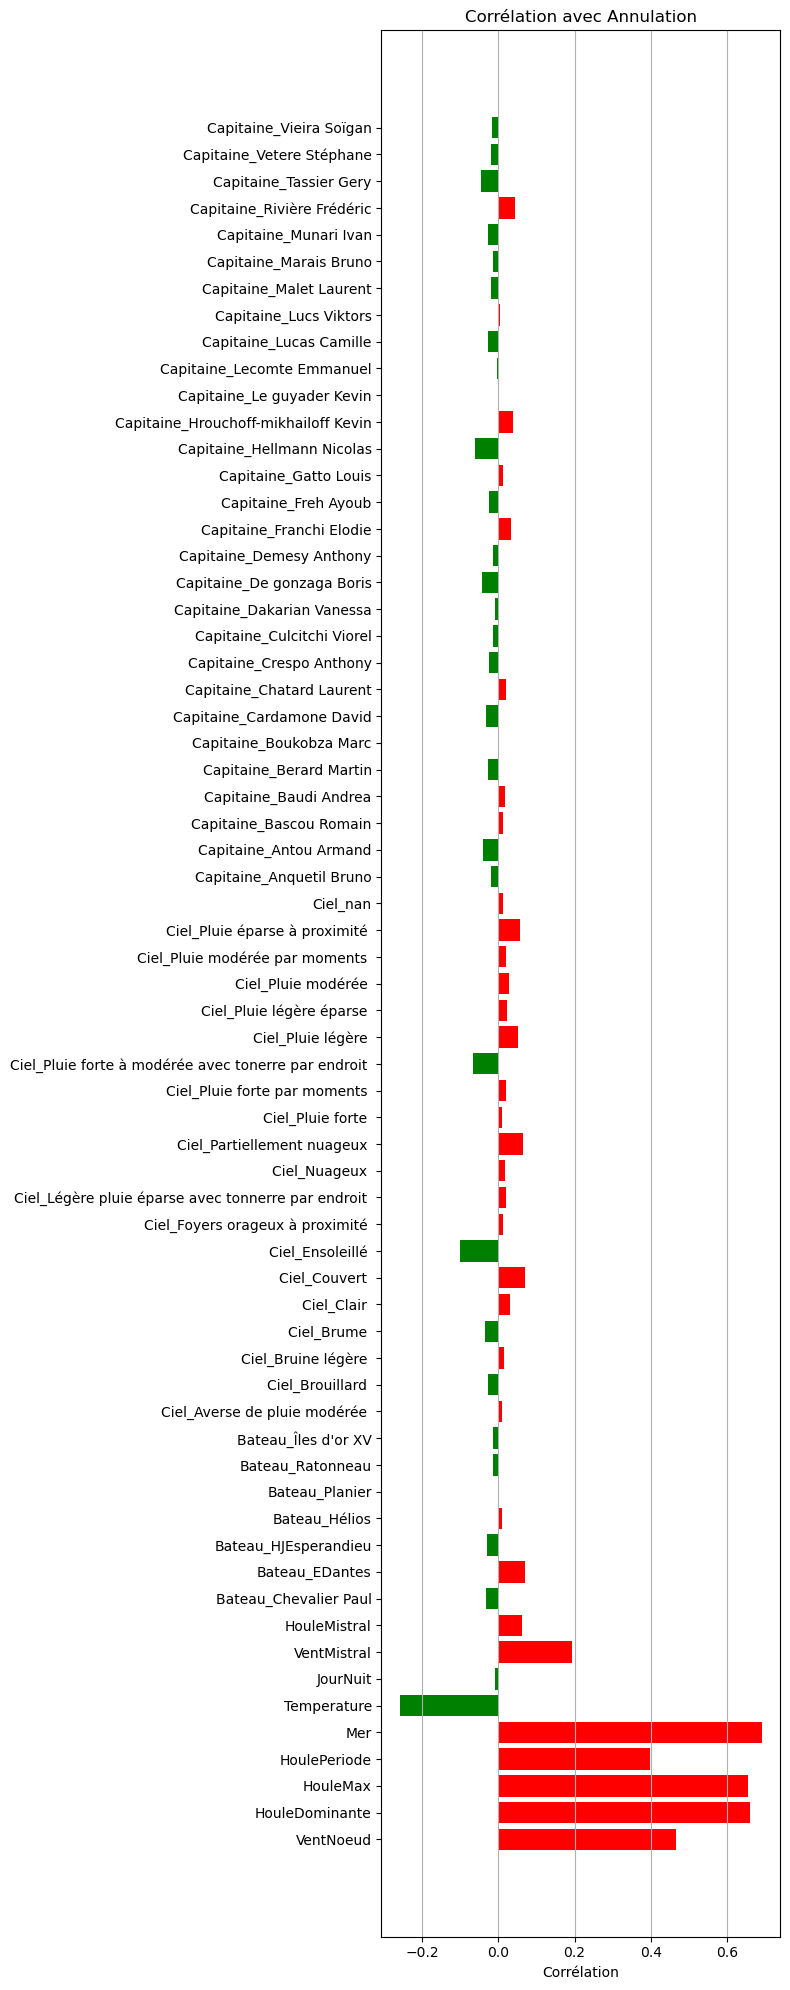

In [80]:
# On récupère les corrélations (hors 'Annulation')
if "Annulation" in corr_cible.index:
    corr_values = corr_cible.drop("Annulation")
else:
    corr_values = corr_cible
variables = corr_values.index
valeurs = corr_values.values

# Applique une couleur différente selon le signe
couleurs = ['green' if v < 0 else 'red' for v in valeurs]

plt.figure(figsize=(8, 20))  # Largeur augmentée pour les étiquettes
bars = plt.barh(variables, valeurs, color=couleurs)
plt.title("Corrélation avec Annulation")
plt.xlabel("Corrélation")
plt.grid(True, axis='x')

plt.tight_layout()  # Ajuste automatiquement la disposition pour éviter le rognage
# plt.savefig("../exports/correlations_annulation_VP_frioul.png")
plt.show()


In [ ]:
# Supposons que corr_cible est déjà trié et sans 'Annulation'
if "Annulation" in corr_cible.index:
    corr_values = corr_cible.drop("Annulation")
else:
    corr_values = corr_cible
# corr_values = corr_cible.drop("Annulation")
variables = corr_values.index
valeurs = corr_values.values
couleurs = ['green' if v < 0 else 'red' for v in valeurs]

# Fractionnement en 3 parties
n = len(valeurs)
tiers = n // 3

vars_1 = variables[:tiers]
vals_1 = valeurs[:tiers]
cols_1 = couleurs[:tiers]

vars_2 = variables[tiers:2*tiers]
vals_2 = valeurs[tiers:2*tiers]
cols_2 = couleurs[tiers:2*tiers]

vars_3 = variables[2*tiers:]
vals_3 = valeurs[2*tiers:]
cols_3 = couleurs[2*tiers:]

fig, axes = plt.subplots(1, 3, figsize=(22, 18), sharex=True)

axes[0].barh(vars_1, vals_1, color=cols_1)
axes[0].set_title("Corrélations (partie 1)")
axes[0].set_xlabel("Corrélation")
axes[0].grid(True, axis='x')

axes[1].barh(vars_2, vals_2, color=cols_2)
axes[1].set_title("Corrélations (partie 2)")
axes[1].set_xlabel("Corrélation")
axes[1].grid(True, axis='x')

axes[2].barh(vars_3, vals_3, color=cols_3)
axes[2].set_title("Corrélations (partie 3)")
axes[2].set_xlabel("Corrélation")
axes[2].grid(True, axis='x')

plt.tight_layout()
plt.savefig("../exports/correlations_annulation_split3.png")

In [81]:
# Pour une variable catégorielle déjà encodée
def correlation_modalites(df, variable, target='Annulation'):
    modalite_cols = [col for col in df.columns if col.startswith(variable + '_')]
    return df[modalite_cols + [target]].corr()[target].drop(target)

# Exemple d'utilisation
corr_ciel = correlation_modalites(df, 'Ciel')
corr_capitaine = correlation_modalites(df, 'Capitaine')
print(corr_ciel)
print()
print(corr_capitaine)


Ciel_Averse de pluie modérée                            0.009646
Ciel_Brouillard                                        -0.027165
Ciel_Bruine légère                                      0.015494
Ciel_Brume                                             -0.035110
Ciel_Clair                                              0.030211
Ciel_Couvert                                            0.070107
Ciel_Ensoleillé                                        -0.100890
Ciel_Foyers orageux à proximité                         0.010955
Ciel_Légère pluie éparse avec tonnerre par endroit      0.020109
Ciel_Nuageux                                            0.016519
Ciel_Partiellement nuageux                              0.063553
Ciel_Pluie forte                                        0.009646
Ciel_Pluie forte par moments                            0.018978
Ciel_Pluie forte à modérée avec tonerre par endroit    -0.065540
Ciel_Pluie légère                                       0.052107
Ciel_Pluie légère éparse 

## Avant réduction des dimensions Bateau_, Ciel_ et Capitaine_
- Séparation des features / cible
- Test d'un modèle 

In [103]:
X = df.drop(columns=['Annulation'])
X = X.select_dtypes(include=['number', 'bool'])

y = df[['Annulation']]
print("X :", X.shape, "y :", y.shape)

X : (6723, 65) y : (6723, 1)


In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# model = RandomForestClassifier()
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
model.score(X_test, y_test)
# print("Accuracy :", model.score(X_test, y_test))

c:\Users\bcoulet\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

           0       0.84      0.86      0.85       751
           1       0.89      0.87      0.88       930

    accuracy                           0.86      1681
   macro avg       0.86      0.86      0.86      1681
weighted avg       0.87      0.86      0.87      1681



0.8649613325401546

## Après réduction des dimensions Bateau_, Ciel_ et Capitaine_
- Séparation des features / cible
- Test d'un modèle 

In [105]:
X = df.drop(columns=['Annulation'])
X = X.select_dtypes(include=['number', 'bool'])
cols_to_drop = [col for col in df.columns if col.startswith('Ciel_') or col.startswith('Bateau_') or col.startswith('Capitaine_')]
X_reduced = X.drop(columns=cols_to_drop)

y = df[['Annulation']]
# print("X :", X_reduced.shape, "y :", y.shape)

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, stratify=y, random_state=42)

# model = RandomForestClassifier()
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
model.score(X_test, y_test)

c:\Users\bcoulet\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

           0       0.84      0.86      0.85       751
           1       0.88      0.87      0.88       930

    accuracy                           0.86      1681
   macro avg       0.86      0.86      0.86      1681
weighted avg       0.87      0.86      0.87      1681



0.8649613325401546

precision : Parmi les prédictions positives, combien étaient correctes ?
(TP / (TP + FP))

recall (rappel) : Parmi les vrais positifs, combien ont été retrouvés ?
(TP / (TP + FN))

f1-score : Moyenne harmonique entre précision et rappel.
(2 * precision * recall / (precision + recall))

support : Nombre d’échantillons réels de chaque classe dans le test

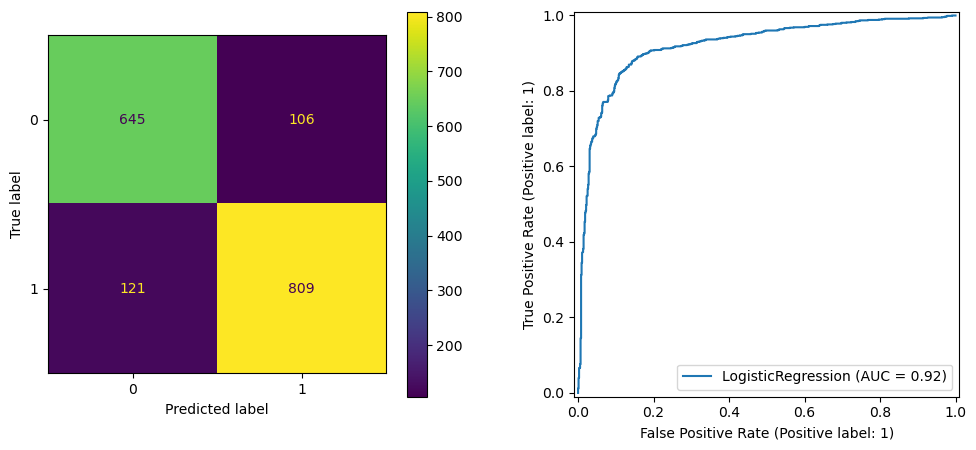

In [102]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0])
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax[1])
plt.show()


## Export du dataset

In [ ]:
# # Réintegre la cible dans le DataFramer
# X_reduced['Annulation'] = y

# # Export du DataFrame réduit
# # X_reduced.to_csv('../data/VP_frioul_if_reduit.csv', index=True)
# # X_reduced.to_csv('../data/VP_frioul_reduit.csv', index=True)
# X_reduced.to_csv('../data/VP_If_reduit.csv', index=True)
